In [1]:
import os
import json
import random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.windows import Window
from rasterio.mask import mask

from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from data_loader import (
    load_dem, load_infiltration_map, load_landuse_map, load_manila_mask, load_all_flood_maps, get_raster_stats, print_raster_stats,
    load_all_rainfall_scenarios, get_rainfall_stats, print_rainfall_stats, visualize_raster, visualize_flood_maps_grid
)


RANDOM_SEED = 42
NUM_TRAIN = 15
NUM_TEST = 5
NUM_SCENARIO = 20
PATCH_SIZE = 4

# Hyperparameters
BATCH_SIZE = 32
NUM_WORKERS = 4     
PIN_MEMORY = False


In [2]:
repo_root = os.getcwd()
gmm_no_manila_path = os.path.join(repo_root, "COP-30m-GMM-ManilaMaskOut")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rs_path = os.path.join(repo_root, "mm_hr_scenarios")

# Loading Data

## Train Data

In [3]:
print("\n--- Loading DEM ---")
dem_path = os.path.join(gmm_no_manila_path, "by_box", "greater_mm_bbox_dem_cop_noManila_box.tif")
if os.path.exists(dem_path):
    train_dem_data, train_dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(train_dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -4.9004
Max value:     466.3908
Mean value:    44.9711
Std dev:       71.0011
Valid pixels:  1,273,959 / 1,377,000



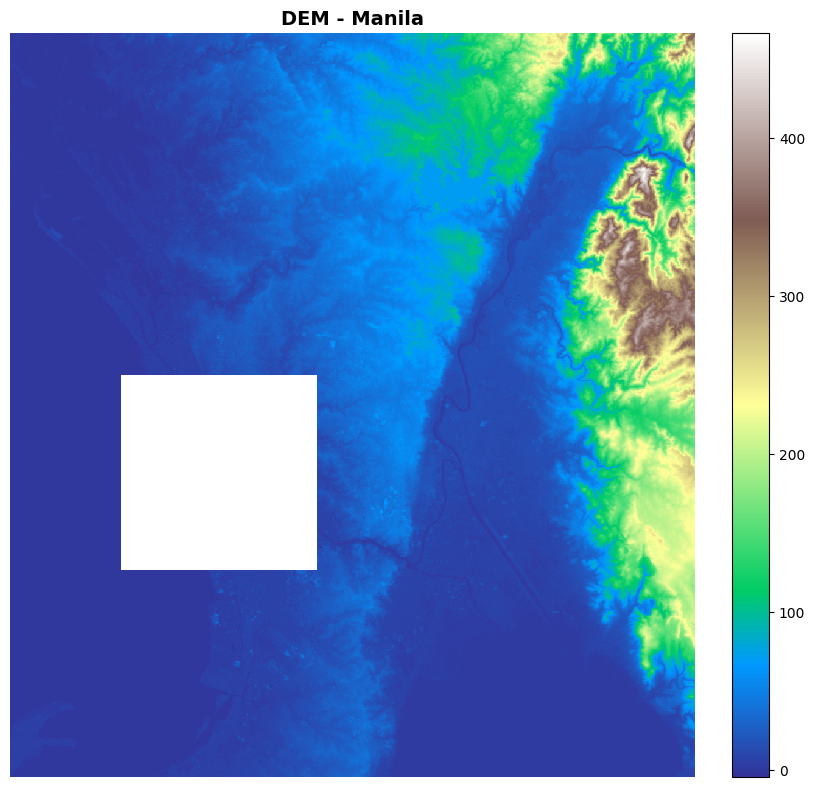

In [4]:
fig1 = visualize_raster(train_dem_data, title="DEM - Manila", cmap='terrain')


In [5]:
# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(gmm_no_manila_path, "by_box", "GM_Infilt_noManila_box.tif")
if os.path.exists(infilt_path):
    train_infilt_data, train_infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(train_infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     3.6847
Mean value:    0.5198
Std dev:       0.9750
Valid pixels:  1,273,959 / 1,377,000



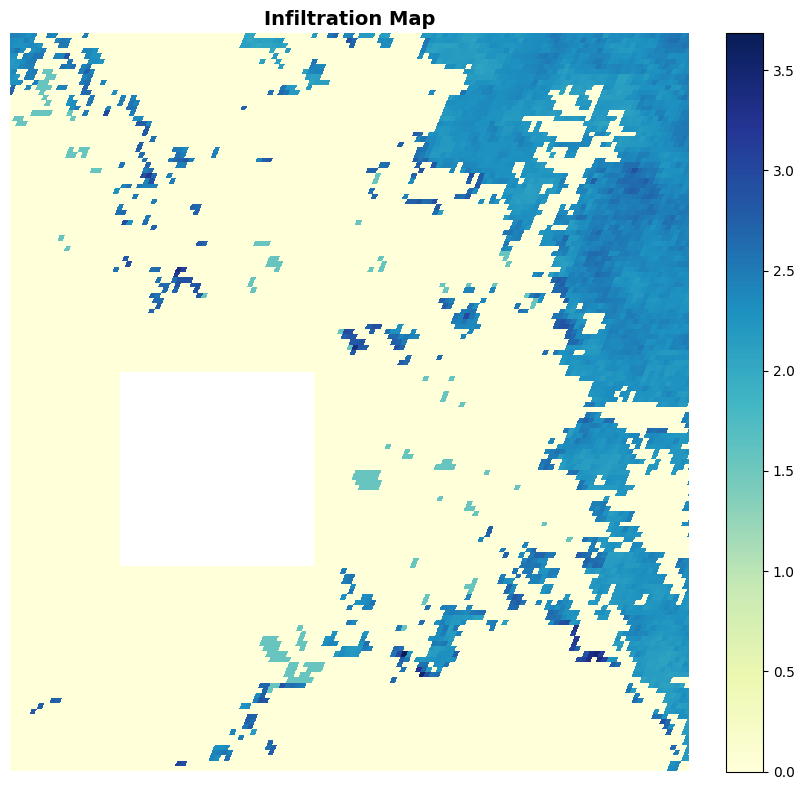

In [6]:
fig2 = visualize_raster(train_infilt_data, title="Infiltration Map", cmap='YlGnBu')

In [7]:
print("\n--- Loading Landuse Map ---")
landuse_path = os.path.join(gmm_no_manila_path, "by_box", "GM_LU_noManila_box.tif")
if os.path.exists(landuse_path):
    train_landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(train_landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    4.8709
Std dev:       2.5478
Valid pixels:  1,273,959 / 1,377,000



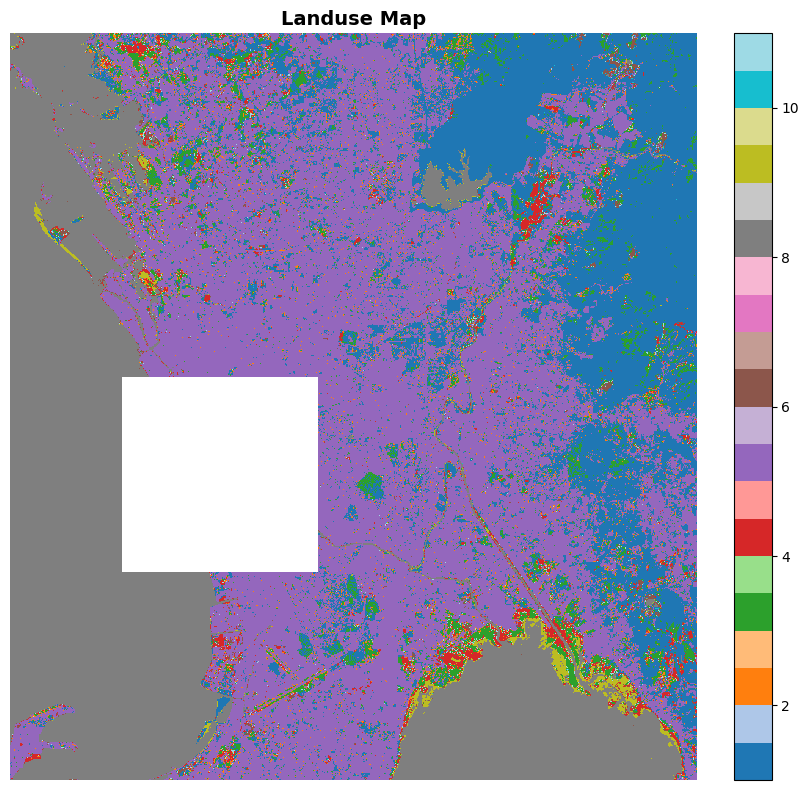

In [8]:
fig3 = visualize_raster(train_landuse_data, title="Landuse Map", cmap='tab20')

In [9]:
# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(gmm_no_manila_path, "by_box")
flood_maps, flood_metadata = load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps)}")
    
    if len(flood_maps) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 1125), dtype float64
Flood map RS3 loaded: shape (1224, 1125), dtype float64
Flood map RS4 loaded: shape (1224, 1125), dtype float64
Flood map RS5 loaded: shape (1224, 1125), dtype float64
Flood map RS6 loaded: shape (1224, 1125), dtype float64
Flood map RS7 loaded: shape (1224, 1125), dtype float64
Flood map RS8 loaded: shape (1224, 1125), dtype float64
Flood map RS9 loaded: shape (1224, 1125), dtype float64
Flood map RS10 loaded: shape (1224, 1125), dtype float64
Flood map RS11 loaded: shape (1224, 1125), dtype float64
Flood map RS12 loaded: shape (1224, 1125), dtype float64
Flood map RS13 loaded: shape (1224, 1125), dtype float64
Flood map RS14 loaded: shape (1224, 1125), dtype float64
Flood map RS15 loaded: shape (1224, 1125), dtype float64
Flood map RS16 loaded: shape (1224, 1125), dtype float64
Flood map RS17 loaded: shape (1224, 1125), dtype float

In [10]:
print_raster_stats(flood_stats)


Statistics for: Flood Map RS20
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     11.2650
Mean value:    0.2657
Std dev:       0.5470
Valid pixels:  1,273,959 / 1,377,000



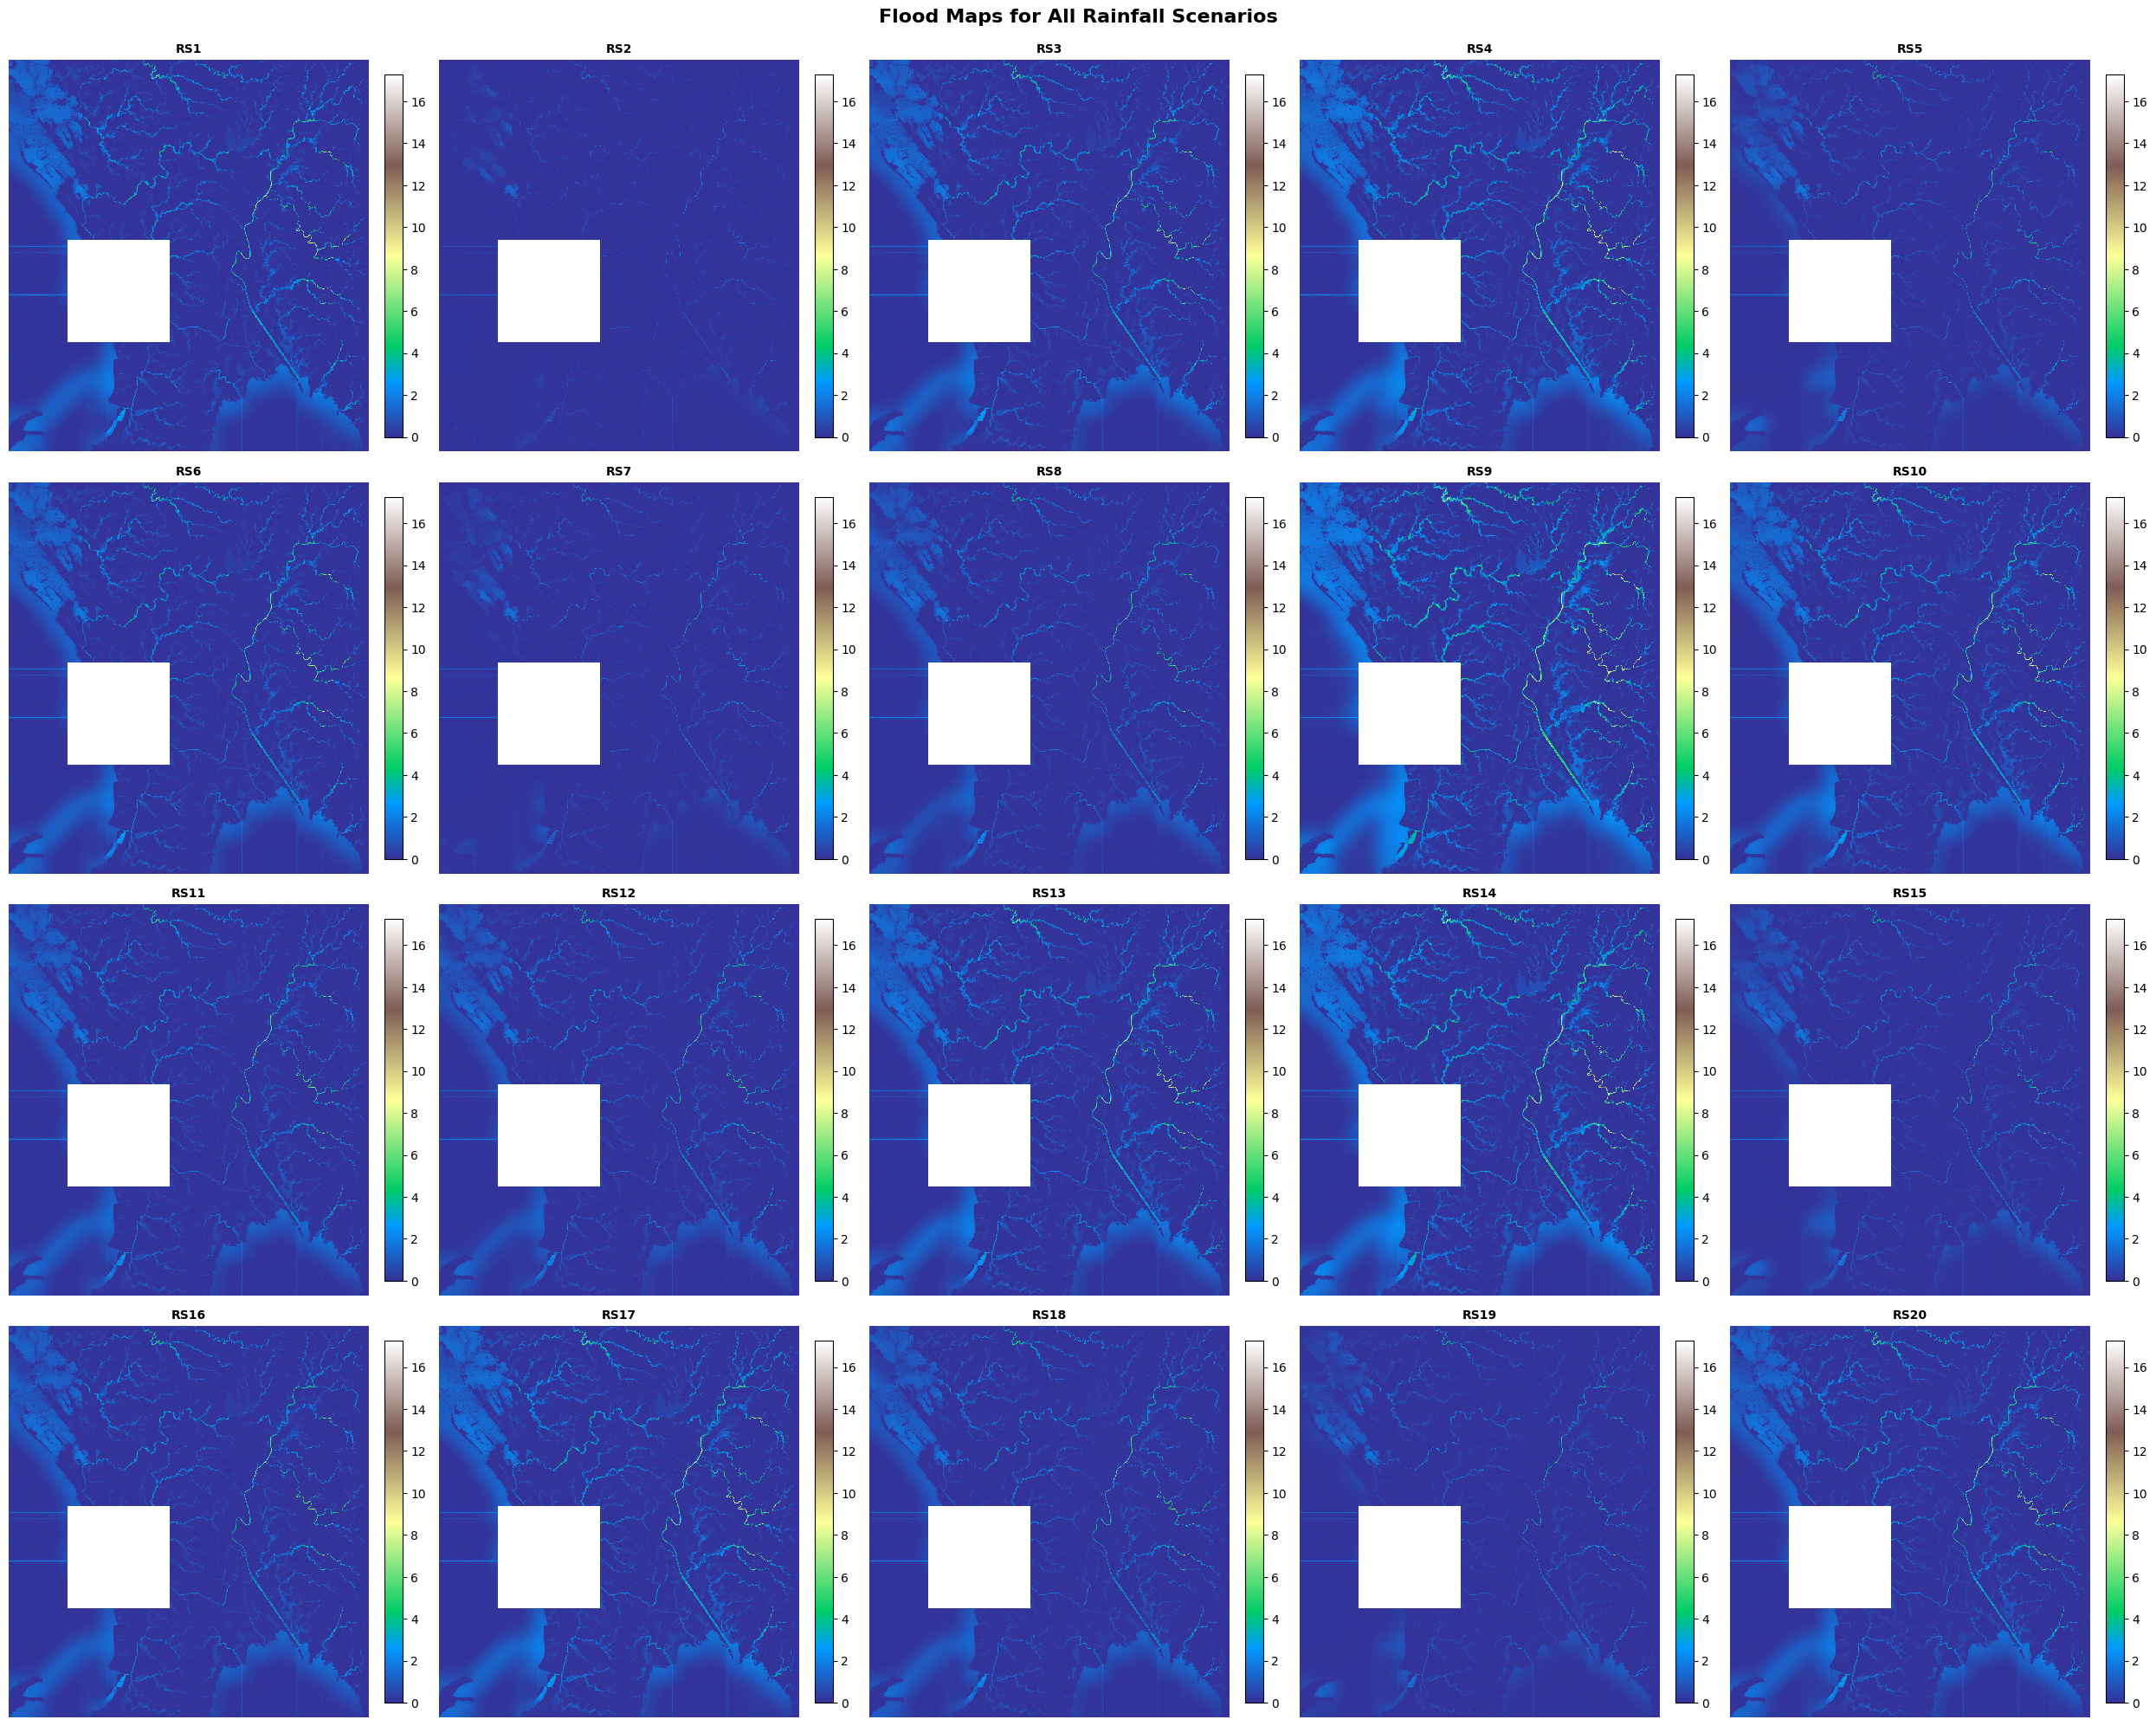

In [11]:
fig4 = visualize_flood_maps_grid(flood_maps=flood_maps,scenario_ids=list(range(1, 21)),figsize=(25, 20),ncols=5,cmap='terrain')

In [12]:
print("LOADING RAINFALL SCENARIOS")
# Load rainfall scenarios
rainfall_scenarios = load_all_rainfall_scenarios(rs_path, num_scenarios=20)

if len(rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(rainfall_scenarios)}")
    
    if len(rainfall_scenarios) >= NUM_SCENARIO:
        rain_stats = get_rainfall_stats(rainfall_scenarios[-1], scenario_id=20)
else:
    print("WARNING: No rainfall scenarios loaded!")

LOADING RAINFALL SCENARIOS
Rainfall Scenario 1 loaded: 13 time steps
Rainfall Scenario 2 loaded: 13 time steps
Rainfall Scenario 3 loaded: 13 time steps
Rainfall Scenario 4 loaded: 13 time steps
Rainfall Scenario 5 loaded: 13 time steps
Rainfall Scenario 6 loaded: 13 time steps
Rainfall Scenario 7 loaded: 13 time steps
Rainfall Scenario 8 loaded: 13 time steps
Rainfall Scenario 9 loaded: 13 time steps
Rainfall Scenario 10 loaded: 13 time steps
Rainfall Scenario 11 loaded: 13 time steps
Rainfall Scenario 12 loaded: 13 time steps
Rainfall Scenario 13 loaded: 13 time steps
Rainfall Scenario 14 loaded: 13 time steps
Rainfall Scenario 15 loaded: 13 time steps
Rainfall Scenario 16 loaded: 13 time steps
Rainfall Scenario 17 loaded: 13 time steps
Rainfall Scenario 18 loaded: 13 time steps
Rainfall Scenario 19 loaded: 13 time steps
Rainfall Scenario 20 loaded: 13 time steps

Total rainfall scenarios loaded: 20

Rainfall scenarios successfully loaded: 20


In [13]:
print_rainfall_stats(rain_stats)
display(rainfall_scenarios)


Rainfall Scenario 20 Statistics
Duration:          1.00 hours
Time steps:        13
Max intensity:     78.8855 mm/hr
Mean intensity:    43.3846 mm/hr
Total rainfall:    47.00 mm
Peak at hour:      0.4167



[        hour  intensity_mmhr
 0   0.000000       39.722227
 1   0.083333       82.817226
 2   0.166667       92.492529
 3   0.250000       82.988129
 4   0.333333       64.674010
 5   0.416667       44.595223
 6   0.500000       27.016951
 7   0.583333       13.969586
 8   0.666667        5.793798
 9   0.750000        1.685605
 10  0.833333        0.241450
 11  0.916667        0.003265
 12  1.000000        0.000000,
         hour  intensity_mmhr
 0   0.000000        6.271931
 1   0.083333       13.076404
 2   0.166667       14.604084
 3   0.250000       13.103389
 4   0.333333       10.211686
 5   0.416667        7.041351
 6   0.500000        4.265834
 7   0.583333        2.205724
 8   0.666667        0.914810
 9   0.750000        0.266148
 10  0.833333        0.038124
 11  0.916667        0.000515
 12  1.000000        0.000000,
         hour  intensity_mmhr
 0   0.000000       35.540940
 1   0.083333       74.099623
 2   0.166667       82.756473
 3   0.250000       74.252536
 4   0.3

## Test Data

# Data Preprocessing